# High Frequency Data and Limit Order Books
## Lab 5: Propagator Models

AMRI Imad, CHIBA Nesrine, JAMAL Adonis

This notebook implements the propagator models for trades and LOB events as described in Lecture 6 and Eisler et al. (2012).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc

In [2]:
# Load all trades and updates
print("Loading data...")
trades = np.array([[pd.read_csv(f"Data/stock{i}_day{j}_trades.csv.gz") for i in range(0, 3)] for j in range(0, 5)], dtype=object)
df_trades = pd.concat([df.assign(stock=i, day=j) for (j, i), df in np.ndenumerate(trades)], ignore_index=True)

updates = np.array([[pd.read_csv(f"Data/stock{i}_day{j}_updates.csv.gz") for i in range(0, 3)] for j in range(0, 5)], dtype=object)
df_updates = pd.concat([df.assign(stock=i, day=j) for (j, i), df in np.ndenumerate(updates)], ignore_index=True)
del trades, updates
gc.collect()

df_trades['ts'] = pd.to_datetime(df_trades['ts'])
df_updates['ts'] = pd.to_datetime(df_updates['ts'])

print("Total trades:", len(df_trades))

Loading data...
Total trades: 259694


## Part 1: A propagator model for trades

1. Compute the response function for trades in trade time

Processing stock 0...
Processing stock 1...
Processing stock 2...


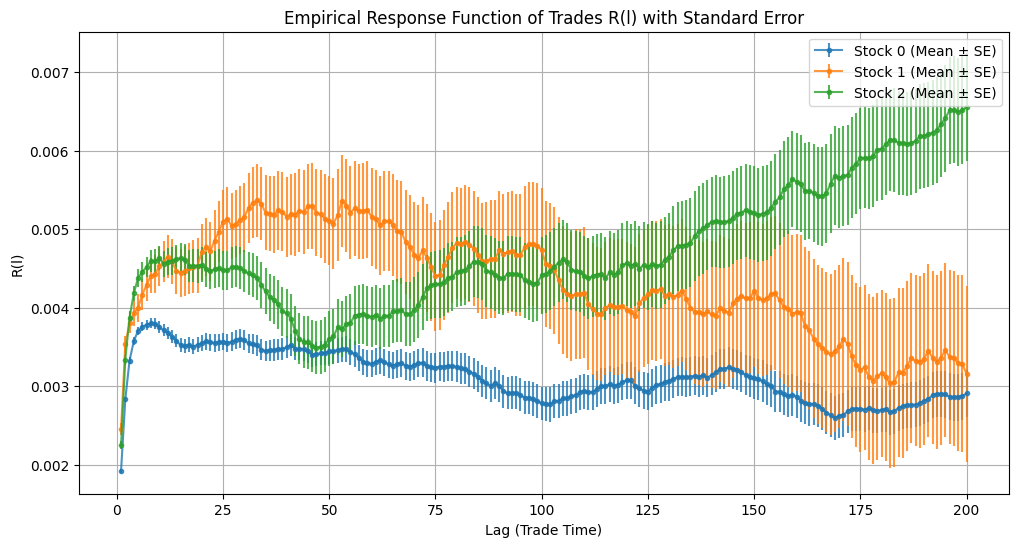

In [3]:
# Process stock by stock
stocks = [0, 1, 2]
lags = np.arange(1, 201)

stock_R = {}
stock_R_std = {}
stock_S_history = {}
stock_r_history = {}

plt.figure(figsize=(12, 6))

for s in stocks:
    print(f"Processing stock {s}...")
    df_t_s = df_trades[df_trades['stock'] == s].copy()
    df_u_s = df_updates[df_updates['stock'] == s].copy()
    
    # Aggregate across days, keep track of day boundaries
    sum_responses = np.zeros(len(lags))
    sum_sq_responses = np.zeros(len(lags))
    count_responses = np.zeros(len(lags))
    
    all_S_for_stock = []
    all_r_for_stock = []
    
    for d in range(5):
        t_day = df_t_s[df_t_s['day'] == d].sort_values('ts')
        u_day = df_u_s[df_u_s['day'] == d].sort_values('ts')
        
        # Merge_asof to get mid price just before trade
        t_day = pd.merge_asof(t_day, u_day[['ts', 'bp', 'ap']], on='ts', direction='backward')
        t_day = t_day.dropna(subset=['bp', 'ap']).copy()
        
        t_day['mid'] = (t_day['bp'] + t_day['ap']) / 2
        t_day['sign'] = np.where(t_day['price'] >= t_day['ap'], 1, 
                                 np.where(t_day['price'] <= t_day['bp'], -1, 0))
        t_day = t_day[t_day['sign'] != 0].copy()
        
        S = t_day['sign'].values
        P = t_day['mid'].values
        r = np.diff(P) # r_n = p_{n+1} - p_n
        
        all_S_for_stock.append(S)
        all_r_for_stock.append(r)
        
        for idx, l in enumerate(lags):
            if len(P) > l:
                shift_P = P[l:]
                valid_S = S[:-l]
                valid_P = P[:-l]
                
                resp = (shift_P - valid_P) * valid_S
                sum_responses[idx] += np.sum(resp)
                sum_sq_responses[idx] += np.sum(resp**2)
                count_responses[idx] += len(valid_S)
    
    # Aggregate R(l) for the stock
    R_l = sum_responses / count_responses
    # standard deviation of the response: sqrt( E[X^2] - E[X]^2 )
    std_l = np.sqrt(np.maximum(0, sum_sq_responses / count_responses - R_l**2))
    # Standard error of the mean
    stderr_l = std_l / np.sqrt(count_responses)
    
    stock_R[s] = R_l
    stock_R_std[s] = std_l
    stock_S_history[s] = all_S_for_stock
    stock_r_history[s] = all_r_for_stock
    
    # Plotting with error bands
    plt.errorbar(lags, R_l, yerr=stderr_l, marker='.', label=f'Stock {s} (Mean ± SE)', alpha=0.8)

plt.title('Empirical Response Function of Trades R(l) with Standard Error')
plt.xlabel('Lag (Trade Time)')
plt.ylabel('R(l)')
plt.legend()
plt.grid(True)
plt.show()

2. Calibrate a propagator model for trades.

Stock 0 C(l) vs R(l) MSE: 9.804408e-11
Stock 1 C(l) vs R(l) MSE: 5.449378e-08
Stock 2 C(l) vs R(l) MSE: 8.319265e-10


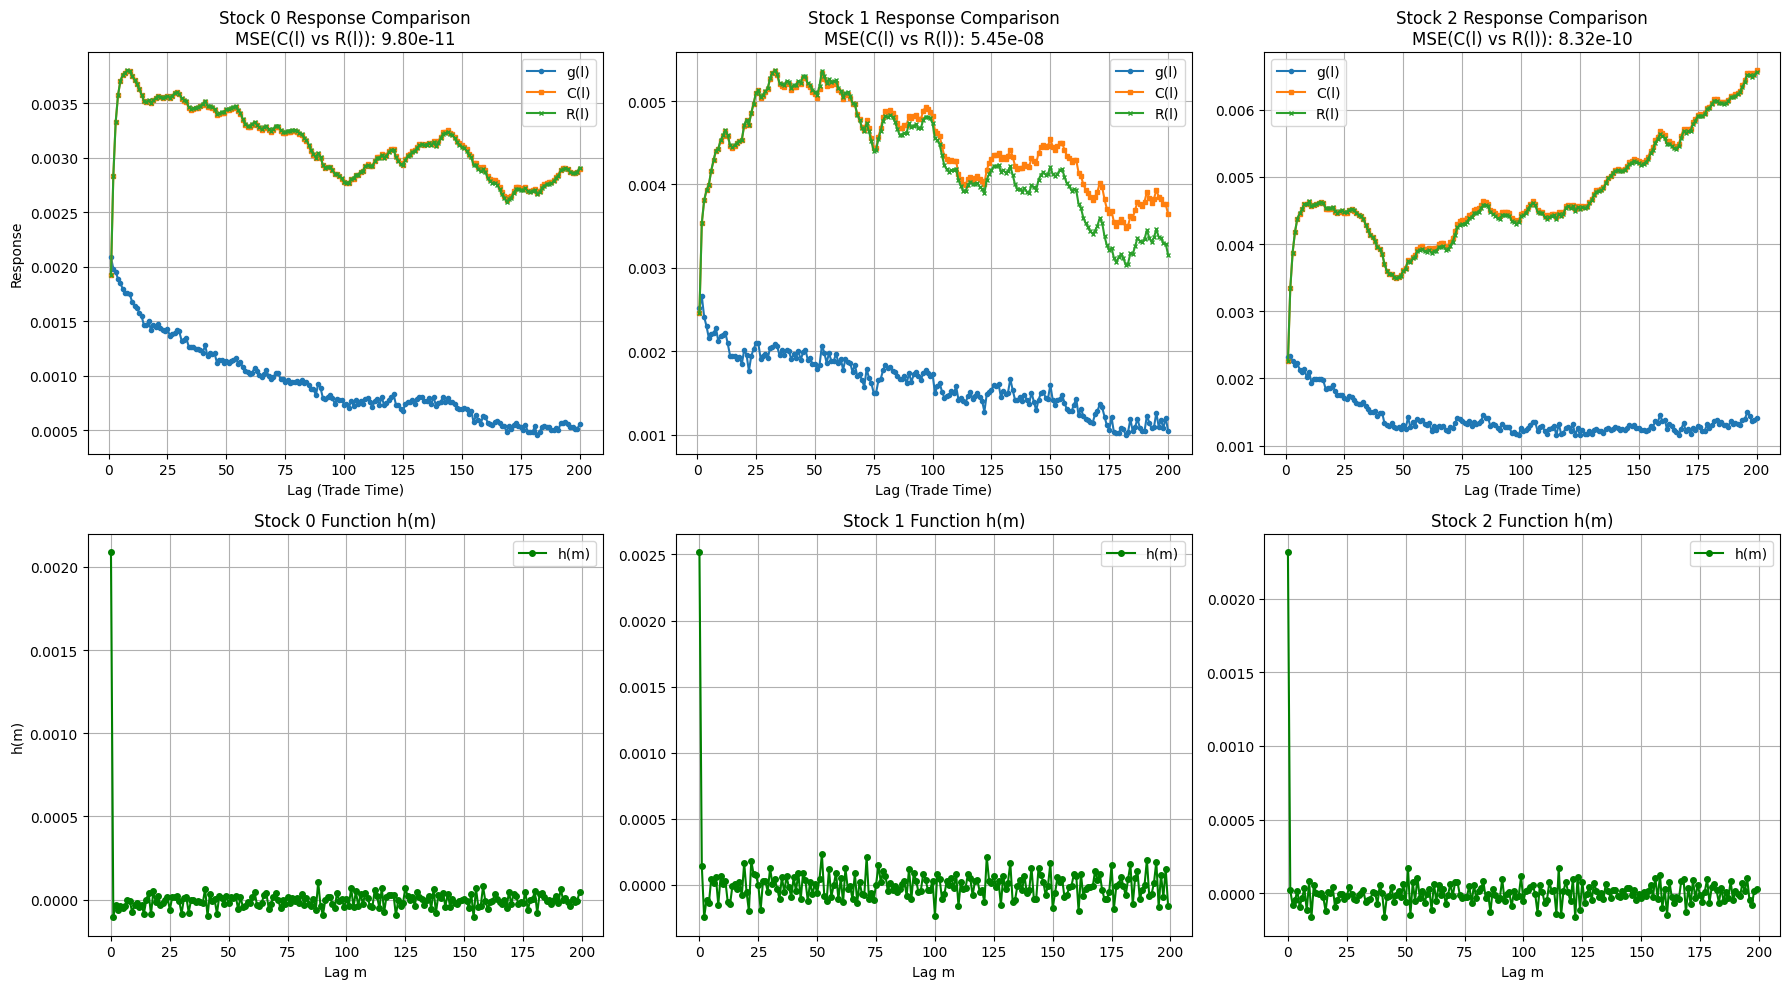

In [4]:
L = 200 # truncate at lag L
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx_s, s in enumerate(stocks):
    # Aggregate C(k) and C_re(l) across days
    sum_C = np.zeros(L)
    count_C = np.zeros(L)
    sum_Cre = np.zeros(L)
    count_Cre = np.zeros(L)
    
    for S, r in zip(stock_S_history[s], stock_r_history[s]):
        N = len(S)
        Nr = len(r)
        
        for k in range(L):
            if N > k:
                if k == 0:
                    sum_C[k] += np.sum(S * S)
                    count_C[k] += N
                else:
                    sum_C[k] += np.sum(S[:-k] * S[k:])
                    count_C[k] += (N - k)
        
        for l in range(L):
            if Nr > l:
                sum_Cre[l] += np.sum(r[l:] * S[:Nr-l])
                count_Cre[l] += (Nr - l)
                
    C = sum_C / count_C
    C_re = sum_Cre / count_Cre
    
    # Linear system: C_re(l) = sum_{m=0}^{L-1} h(m) C(|l-m|)
    M = np.array([[C[abs(i - j)] for j in range(L)] for i in range(L)])
    h = np.linalg.solve(M, C_re)
    
    # Recover g(l)
    g = np.zeros(L + 1)
    g[1:] = np.cumsum(h)
    g_plot = g[1:]

    # Since R(l) = E[(p_{n+l} - p_n) * e_n]
    # Calibration using the sign-return lagged covariance: E[r_{n+l} * e_n] with r_n = p_{n+1} - p_n
    C_model = np.zeros(L)
    for l in range(1, L + 1):
        total = 0.0
        for j in range(l):
            for m in range(L):
                total += h[m] * C[abs(j - m)]
        C_model[l - 1] = total

    R_trunc = stock_R[s][:L]
    mse_model = np.mean((C_model - R_trunc)**2)
    print(f"Stock {s} C(l) vs R(l) MSE: {mse_model:.6e}")

    ax_g = axes[0, idx_s]
    ax_g.plot(np.arange(1, L+1), g_plot, label='g(l)', marker='o', markersize=3)
    ax_g.plot(np.arange(1, L+1), C_model, label='C(l)', marker='s', markersize=3)
    ax_g.plot(np.arange(1, L+1), R_trunc, label='R(l)', marker='x', markersize=3)
    ax_g.set_title(f'Stock {s} Response Comparison\nMSE(C(l) vs R(l)): {mse_model:.2e}')
    ax_g.set_xlabel('Lag (Trade Time)')
    if idx_s == 0: ax_g.set_ylabel('Response')
    ax_g.legend()
    ax_g.grid(True)
    
    # h(m)
    ax_h = axes[1, idx_s]
    ax_h.plot(np.arange(0, L), h, label='h(m)', marker='o', markersize=4, color='green')
    ax_h.set_title(f'Stock {s} Function h(m)')
    ax_h.set_xlabel('Lag m')
    if idx_s == 0: ax_h.set_ylabel('h(m)')
    ax_h.legend()
    ax_h.grid(True)

plt.tight_layout()
plt.show()

3. Comment.

<blockquote>

For each of the three stocks, the function $h(m)$ initially decreases rapidly as the lag increases from 0, but then stabilizes starting from $m \approx 2$. This reflects the direct impact of a trade on future price changes is strongest immediately after the trade, but quickly weakens as more trades occur.

$g(l)$ and $\mathcal{R}(l)$ do not coincide exactly. The equality $\mathcal{R}(l) = g(l)$ is true if $\epsilon_s$'s are i.i.d. which is clearly not the case here. This shows the presence of memory and correlation in the order flow: trade signs are not independent, and this autocorrelation structure must be accounted for in the model. So while the $\epsilon_n$'s are correlated, the lag-1 returns $r_n$ should not be.

We thus check the calibration using the sign-return lagged covariance $C^{r, \epsilon} (l) = \mathbb{E}[r_{n+l} \epsilon_n] = \sum_{m \geq 0} h(m) C(|m - l|)$. Comparing the result to the $\mathcal{R}(l)$, we find a much better agreement, with MSE values of the order of $10^{-8}$ or even smaller, as the two curves are almost indistinguishable for small lag values. This shows that the propagator model can accurately capture the average price response when the true correlation structure of the order flow is included, and can describe the impact of trades on prices as long as the correct order flow statistics are used.

In practice, this figure shows that while the immediate impact of a trade is important, the history and correlation of past trades play an important role in the shape of the observed price dynamics.

It is important to note that the MSE between $\mathcal{R}(l)$ and $g(l)$ is still very small, but comparatively larger than the MSE between $\mathcal{R}(l)$ and $C^{r, \epsilon} (l)$.

</blockquote>

## Part 2: A propagator model for LOB events

Select one stock of your dataset (stock0 or stock1).

We will use stock0.

In [5]:
# 2.0 Prepare event data for stock 0 across all days
stk = 0
df_t_s0 = df_trades[df_trades['stock'] == stk].copy()
df_u_s0 = df_updates[df_updates['stock'] == stk].copy()

# List to hold events per day
events_per_day = []

def classify_lob_event(row):
    t = row['type']
    if t == 'T':
        if row['price'] >= row['ap']:
            sign = 1
        elif row['price'] <= row['bp']:
            sign = -1
        else:
            return 'UNKNOWN', 0, 0.0

        ap_d = row.get('ap_diff', 0) or 0
        bp_d = row.get('bp_diff', 0) or 0
        if (sign == 1 and ap_d > 0) or (sign == -1 and bp_d < 0):
            gap = abs(ap_d if sign == 1 else bp_d) / 2.0
            return "MO'", sign, gap
        else:
            return 'MO0', sign, 0.0

    elif t == 'U':
        ap_d = row.get('ap_diff', 0) or 0
        bp_d = row.get('bp_diff', 0) or 0
        aq_d = row.get('aq_diff', 0) or 0
        bq_d = row.get('bq_diff', 0) or 0

        if bp_d > 0:
            return "LO'", 1, bp_d / 2.0
        if ap_d < 0:
            return "LO'", -1, abs(ap_d) / 2.0

        if bp_d < 0:
            return "CA'", -1, abs(bp_d) / 2.0
        if ap_d > 0:
            return "CA'", 1, ap_d / 2.0

        if bq_d > 0:
            return 'LO0', 1, 0.0
        if aq_d > 0:
            return 'LO0', -1, 0.0

        if bq_d < 0:
            return 'CA0', -1, 0.0
        if aq_d < 0:
            return 'CA0', 1, 0.0

    return 'UNKNOWN', 0, 0.0

for d in range(5):
    u_day = df_u_s0[df_u_s0['day'] == d].sort_values('ts').copy()
    u_day['bp_diff'] = u_day['bp'].diff().fillna(0)
    u_day['bq_diff'] = u_day['bq'].diff().fillna(0)
    u_day['ap_diff'] = u_day['ap'].diff().fillna(0)
    u_day['aq_diff'] = u_day['aq'].diff().fillna(0)
    
    # Trade prices to identify market orders
    t_day = df_t_s0[df_t_s0['day'] == d].sort_values('ts')[['ts', 'price']].copy()
    t_day = t_day.groupby('ts').last().reset_index()
    u_day = pd.merge(u_day, t_day, on='ts', how='left').copy()
    u_day['type'] = np.where(u_day['price'].notna(), 'T', 'U')

    classified = u_day.apply(classify_lob_event, axis=1)
    u_day['event_type'] = [c[0] for c in classified]
    u_day['sign'] = [float(c[1]) for c in classified]
    u_day['gap'] = [c[2] for c in classified]
    u_day['side'] = np.where(u_day['event_type'].str.startswith(('LO', 'CA')), np.sign(u_day['sign']), 0)
    
    u_day = u_day[u_day['event_type'] != 'UNKNOWN'].copy()
    u_day['mid'] = (u_day['bp'] + u_day['ap']) / 2
    u_day.reset_index(drop=True, inplace=True)
    events_per_day.append(u_day.dropna(subset=['mid']))

print(f"Prepared event data for stock {stk} across 5 days.")
print("Event counts day 0:\n", events_per_day[0]['event_type'].value_counts())

Prepared event data for stock 0 across 5 days.
Event counts day 0:
 event_type
LO0    99385
CA0    94043
LO'    10880
CA'     8271
MO0     7191
MO'       16
Name: count, dtype: int64


1. Plot the sign $\langle \epsilon_{t}, \epsilon_{t+l} \rangle$ and side autocorrelation $\langle s_t, s_{t+l} \rangle$ functions.

C:\Users\adoni\AppData\Local\Temp\ipykernel_22716\2544503486.py:23: RuntimeWarning: invalid value encountered in divide
  sign_acf /= counts_acf
C:\Users\adoni\AppData\Local\Temp\ipykernel_22716\2544503486.py:24: RuntimeWarning: invalid value encountered in divide
  side_acf /= counts_acf


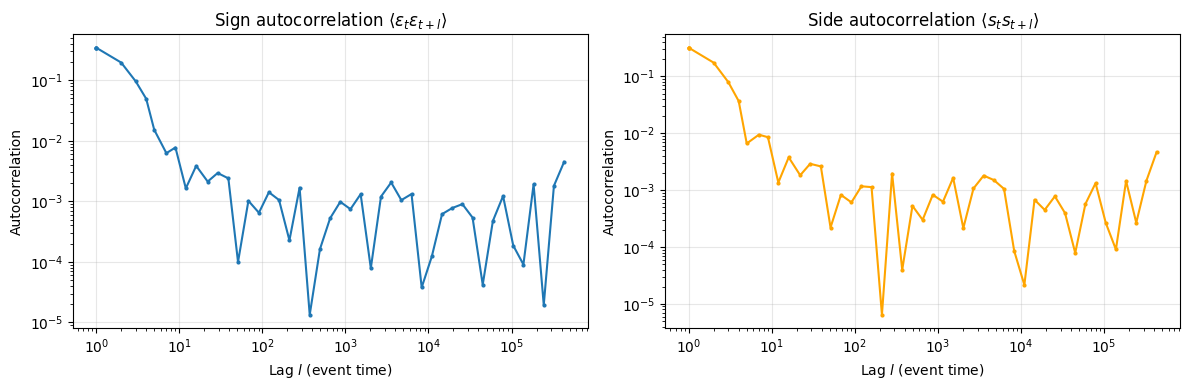

In [6]:
lags = np.logspace(0.0, 6.0, num=50, dtype=int)
sign_acf = np.zeros(len(lags))
side_acf = np.zeros(len(lags))
counts_acf = np.zeros(len(lags))

for u_day in events_per_day:
    S = u_day['sign'].values
    Side = u_day['side'].values
    
    for idx, l in enumerate(lags):
        if len(S) > l:
            if l == 0:
                shift_S, shift_Side = S, Side
                curr_S, curr_Side = S, Side
            else:
                shift_S, shift_Side = S[l:], Side[l:]
                curr_S, curr_Side = S[:-l], Side[:-l]
            
            sign_acf[idx] += np.sum(curr_S * shift_S)
            side_acf[idx] += np.sum(curr_Side * shift_Side)
            counts_acf[idx] += (len(S) - l)

sign_acf /= counts_acf
side_acf /= counts_acf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].loglog(lags, np.abs(sign_acf), marker='.', markersize=4)
axes[0].set_title(r'Sign autocorrelation $\langle \epsilon_t \epsilon_{t+l} \rangle$')
axes[0].set_xlabel(r'Lag $l$ (event time)')
axes[0].set_ylabel('Autocorrelation')
axes[0].grid(True, alpha=0.3)

axes[1].loglog(lags, np.abs(side_acf), marker='.', markersize=4, color='orange')
axes[1].set_title(r'Side autocorrelation $\langle s_t s_{t+l} \rangle$')
axes[1].set_xlabel(r'Lag $l$ (event time)')
axes[1].set_ylabel('Autocorrelation')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


We observe in the above autocorrelation plots similar dynamics to those seen in the lecture slides page 39. Notably, both the sign and side autocorrelation functions exhibit a slow decay, indicating the presence of long-range memory in the order flow. Market orders persistently hit one side, and attract liquidity on the same side, which is consistent with the observed positive autocorrelation in both sign and side.

2. Compute and plot the empirical response function $\mathcal{R}_\pi (l)$ for each of the $6$ types of events $\pi$. Comment.

<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
C:\Users\adoni\AppData\Local\Temp\ipykernel_22716\2125669687.py:32: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Empirical Response Functions $\mathcal{R}_\pi(l)$ per Event Type')


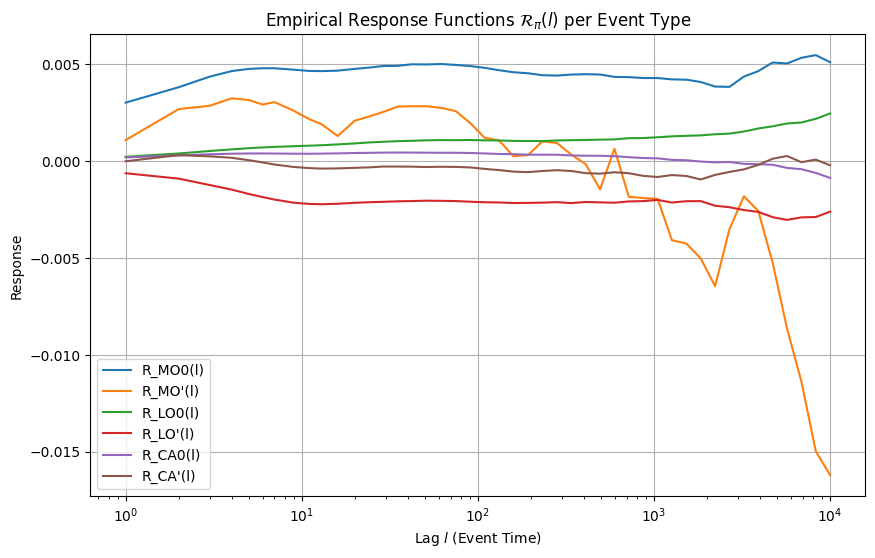

In [7]:
types = ["MO0", "MO'", "LO0", "LO'", "CA0", "CA'"]
lags = np.logspace(0.0, 4.0, num=50, dtype=int)

R_pi_sum = {pi: np.zeros(len(lags)) for pi in types}
R_pi_count = {pi: np.zeros(len(lags)) for pi in types}

for u_day in events_per_day:
    P = u_day['mid'].values
    S = u_day['sign'].values
    E = u_day['event_type'].values
    
    for idx, l in enumerate(lags):
        if len(P) > l:
            shift_P = P[l:]
            valid_P = P[:-l]
            diff_P = shift_P - valid_P
            
            valid_S = S[:-l]
            valid_E = E[:-l]
            
            for pi in types:
                mask = (valid_E == pi)
                if np.sum(mask) > 0:
                    R_pi_sum[pi][idx] += np.sum(diff_P[mask] * valid_S[mask])
                    R_pi_count[pi][idx] += np.sum(mask)

R_pi = {pi: R_pi_sum[pi] / np.maximum(R_pi_count[pi], 1) for pi in types}

plt.figure(figsize=(10, 6))
for pi in types:
    plt.semilogx(lags, R_pi[pi], label=f"R_{pi}(l)")
plt.title('Empirical Response Functions $\mathcal{R}_\pi(l)$ per Event Type')
plt.xlabel('Lag $l$ (Event Time)')
plt.ylabel('Response')
plt.legend()
plt.grid(True)
plt.show()

<blockquote>

The empirical response functions $\mathcal{R}_\pi(l)$ for each event type $\pi$ show distinct behaviors, reflecting the heterogeneous impact of different LOB events on mid-price dynamics.

Market orders ($M^0$, $MO'$) have a pronounced and persistent positive impact on the price, with $\mathcal{R}_{MO^0}(l)$ showing a large initial jump and far slower decay, indicating that...

We do not observe any responses for passive events ($LO^0$, $CA^0$) as these events do not change the best price directly.

Compared to Market orders, limit order insertions ($LO'$) and cancellations ($CA'$), have smaller, negative responses, consistent with their roles in providing or removing liquidity rather than demanding it.

This difference between event types shows the asymmetric nature of order flow impact: aggressive liquidity-taking events ($MO'$, $CA'$) move the price, while passive or liquidity-providing events ($LO^0$, $CA^0$) have little effect.

The decay of $\mathcal{R}_\pi(l)$ with lag $l$ suggests that the market partially absorbs the impact of events over time, but the memory is not negligible, especially for market orders. This also confirms that the type and aggressiveness of an event are key determinants of its price impact.

</blockquote>

3. Compute the signed event-event correlations $C_{\pi_1, \pi_2} (l)$.

In [8]:
lags = np.logspace(0.0, 4.0, num=50, dtype=int)
total_events = sum([len(d) for d in events_per_day])
event_probs = {pi: sum([np.sum(d['event_type'] == pi) for d in events_per_day]) / total_events for pi in types}

C_sum   = {pi1: {pi2: np.zeros(len(lags)) for pi2 in types} for pi1 in types}
C_count = {pi1: {pi2: np.zeros(len(lags)) for pi2 in types} for pi1 in types}

for u_day in events_per_day:
    S = u_day['sign'].values
    E = u_day['event_type'].values
    N = len(S)
    
    for idx, l in enumerate(lags):
        if N > l:
            if l == 0:
                shift_E, shift_S = E, S
                curr_E, curr_S = E, S
            else:
                shift_E, shift_S = E[l:], S[l:]
                curr_E, curr_S = E[:-l], S[:-l]
            
            for pi1 in types:
                mask1 = (curr_E == pi1)
                if not mask1.any(): continue
                for pi2 in types:
                    mask2 = (shift_E == pi2)
                    joint_mask = mask1 & mask2
                    C_sum[pi1][pi2][idx] += np.sum(curr_S[joint_mask] * shift_S[joint_mask])
                    C_count[pi1][pi2][idx] += (N - l)

C_matrix = {}
for pi1 in types:
    C_matrix[pi1] = {}
    for pi2 in types:
        C_matrix[pi1][pi2] = (C_sum[pi1][pi2] / np.maximum(C_count[pi1][pi2], 1)) / (event_probs[pi1] * event_probs[pi2])

C_MO_prime = C_matrix["MO'"]

4. Plot the function $C_{MO',\pi_2} (l)$. Note that a signed log-scale similar to the one presented in [7] can be obtained matplotlib with $\texttt{ax.set\_yscale('symlog')}$.

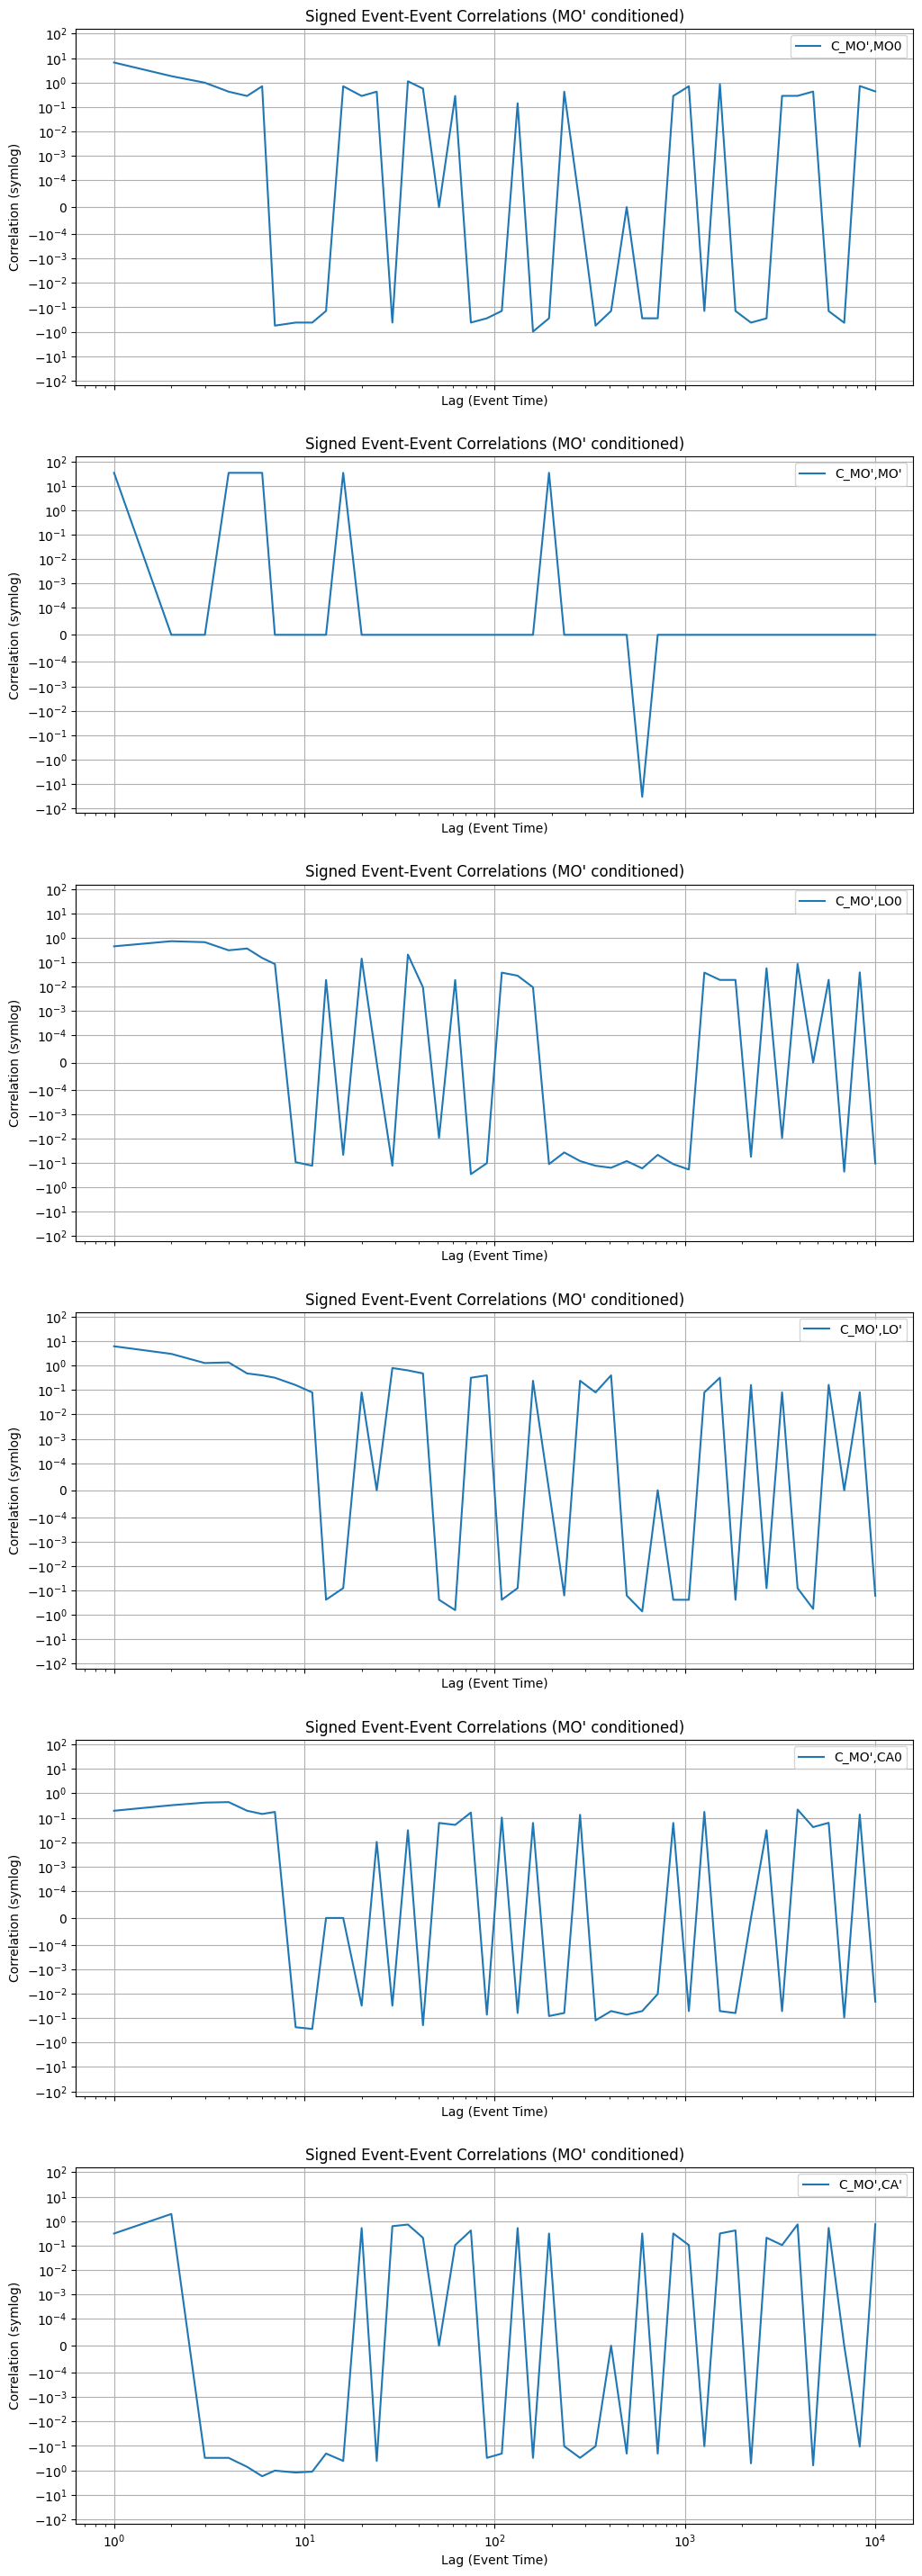

In [9]:
fig, ax = plt.subplots(6, 1, figsize=(12, 36), sharex=True, sharey=True)
ax = ax.flatten()
for i,pi2 in enumerate(types):
    ax[i].semilogx(lags, C_MO_prime[pi2], label=f"C_MO',{pi2}")
    ax[i].set_yscale('symlog', linthresh=1e-4) # from Eisler 2012
    ax[i].set_title("Signed Event-Event Correlations (MO' conditioned)")
    ax[i].set_xlabel('Lag (Event Time)')
    ax[i].set_ylabel('Correlation (symlog)')
    ax[i].legend()
    ax[i].grid(True)
plt.show()

5. Compute the theoretical responses in the constant impact model, and compare them to the empirical ones. Comment.

DeltaR^pi: {'MO0': np.float64(0.0), "MO'": np.float64(0.005320512820512794), 'LO0': np.float64(0.0), "LO'": np.float64(0.0050677615194583145), 'CA0': np.float64(0.0), "CA'": np.float64(0.005058060109289626)}


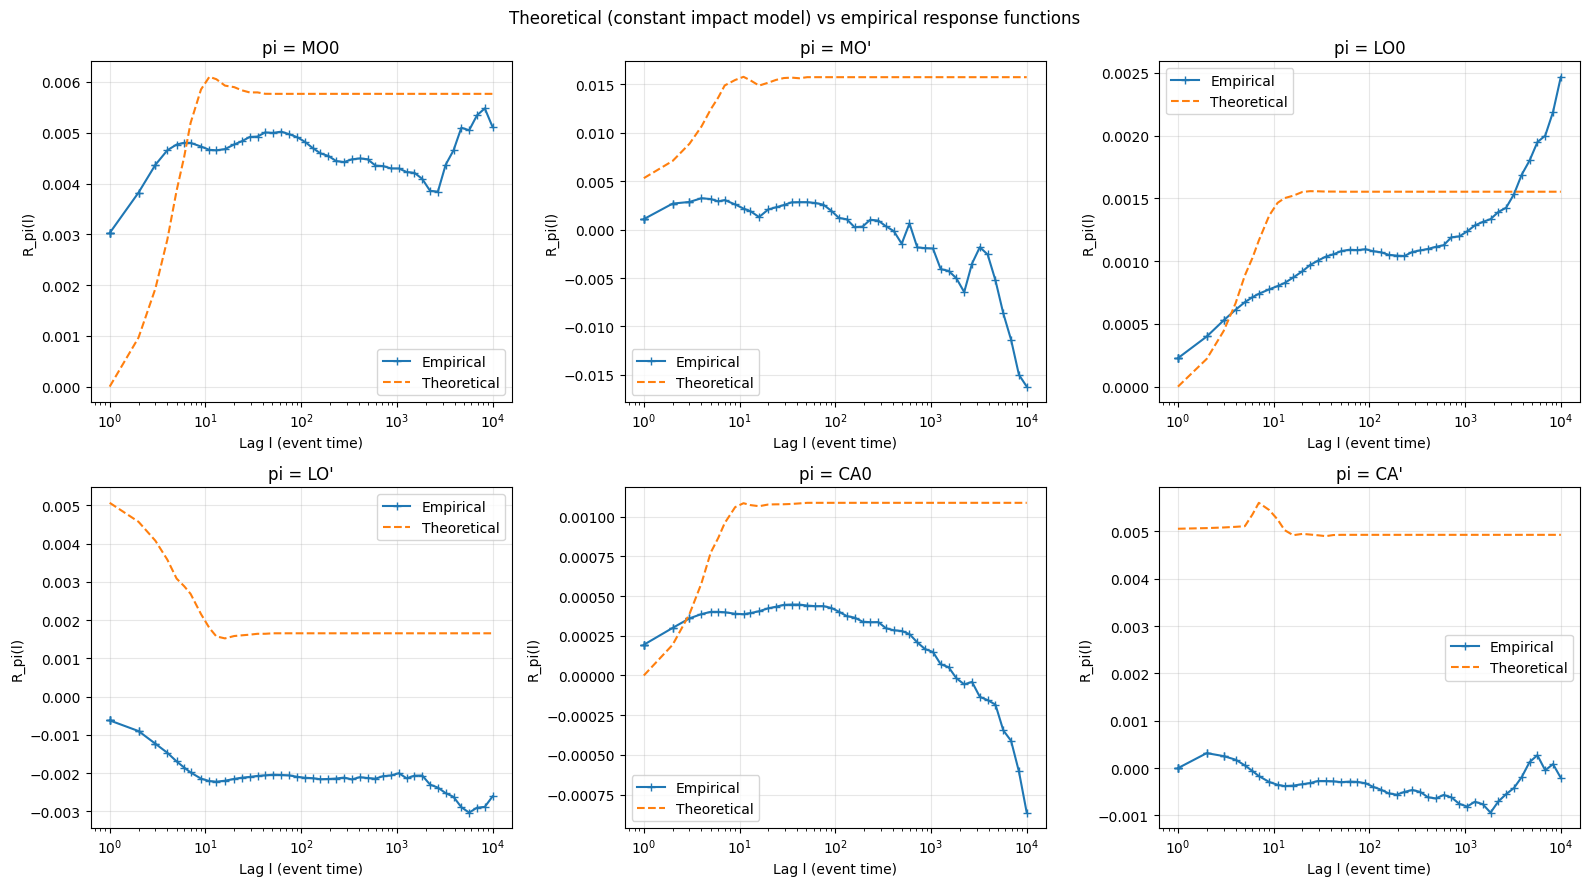

In [ ]:
# Theoretical responses in the constant impact model
# R_pi(l) approx sum_{t'=0}^{l-1} sum_{pi_1} Delta R^{pi_1} P(pi_1) C_{pi, pi_1}(t')

# Delta R^pi = average price change immediately after event pi
delta_R_sum = {pi: 0.0 for pi in types}
delta_R_count = {pi: 0 for pi in types}

for u_day in events_per_day:
    gap_vals = u_day['gap'].values
    etype = u_day['event_type'].values

    for pi in types:
        mask = (etype == pi)
        if mask.any():
            delta_R_sum[pi] += np.sum(gap_vals[mask])
            delta_R_count[pi] += mask.sum()


delta_R = {pi: (delta_R_sum[pi] / delta_R_count[pi] if delta_R_count[pi] > 0 else 0.0) for pi in types}
theoretical_R_pi = {pi: np.zeros(len(lags)) for pi in types}
for l_idx, l in enumerate(lags):
    for pi in types:
        total = 0.0
        for t_prime in range(l):
            for pi1 in types:
                if t_prime == 0:
                    if pi == pi1:
                        c_val = 1.0 / event_probs[pi] if event_probs[pi] > 0 else 0.0
                    else:
                        c_val = 0.0
                else:
                    tp_idx = t_prime - 1
                    c_val = C_matrix[pi][pi1][tp_idx] if tp_idx < len(lags) else 0.0
                total += delta_R[pi1] * event_probs[pi1] * c_val
        theoretical_R_pi[pi][l_idx] = total

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for idx_pi, pi in enumerate(types):
    ax = axes[idx_pi // 3][idx_pi % 3]
    ax.semilogx(lags, R_pi[pi][:len(lags)], label='Empirical', marker='+')
    ax.semilogx(lags, theoretical_R_pi[pi], label='Theoretical', linestyle='--')
    ax.set_title(f'pi = {pi}')
    ax.set_xlabel('Lag l (event time)')
    ax.set_ylabel('R_pi(l)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Theoretical (constant impact model) vs empirical response functions')
plt.tight_layout()
plt.show()

<blockquote>

The theoretical response functions from the constant impact model mostly capture the qualitative shape of the empirical responses, but can slightly over- ($LO'$, $MO'$, $CA'$) or under-estimate ($MO^0$) the empirical response. Once again, no response is observed for passive events $LO^0$ and $CA^0$. This shows that the constant impact assumption is a simplification and real market impact may decay or fluctuate with time and event context.

While it may not seem it, we do in fact observe close agreement at short lags as the scale is of the order of $10^{-3}$, that suggests that the immediate price impact of an event is well-approximated by its average gap. The subsequent evolution is influenced by event-event correlations and market resilience.

We could also explain the discrepancies at longer lags from non-linear effects, state dependence, or unmodeled feedback mechanisms in the order book.

Overall, the comparison validates the propagator framework as a useful first-order model for LOB event impact, but also proves the need for more sophisticated models to fully capture the dynamics observed in real data.

</blockquote>